In [2]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ticker = yf.Ticker("MSFT")
df = pd.DataFrame(ticker.history(period="1y", interval="1h")).reset_index()
df["Mid"] = (df["High"]+df["Low"])/2
df.head()

,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits,Mid
0,2024-12-05 10:30:00-05:00,438.109985,439.880005,437.864594,439.640015,0,0.0,0.0,438.872299
1,2024-12-05 11:30:00-05:00,439.665009,443.799988,439.290009,442.845001,3275028,0.0,0.0,441.544998
2,2024-12-05 12:30:00-05:00,442.839996,444.660004,442.359985,443.380005,2015915,0.0,0.0,443.509995
3,2024-12-05 13:30:00-05:00,443.375000,444.434998,442.340088,442.990112,1941367,0.0,0.0,443.387543
4,2024-12-05 14:30:00-05:00,443.049988,443.500000,442.100006,442.424011,1478752,0.0,0.0,442.800003


In [4]:
val = np.array(df["Mid"])
val[:5]

array([438.87229919, 441.54499817, 443.50999451, 443.38754272,
       442.80000305])

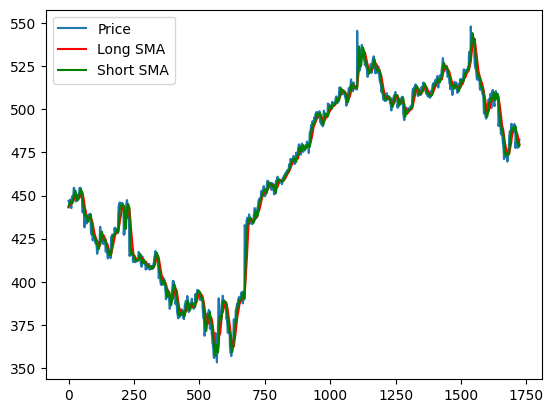

Buy prices: [448.6050415  423.23249817 387.36714172 392.92655945 385.44499207
 458.61099243 458.80731201 460.17500305 474.60499573 486.31996155
 499.22235107 536.68997192 506.9940033  506.63250732 510.853302
 484.58999634]
Sell prices: [446.50999451 427.35499573 382.36500549 389.51000977 450.33999634
 450.92263794 457.90429688 469.42001343 476.81750488 492.81999207
 511.61500549 522.26245117 504.79750061 495.50520325 507.19999695
 480.94999695]
Profit: 45.21797180175781


In [5]:
LONG = 15
SHORT = 7
s_averages = np.array([])
l_averages = np.array([])

buy_prices = np.array([])
sell_prices = np.array([])

position = 0 
entry_price = None

for i in range(len(val)):
    if i < LONG:
        continue

    long_sma = np.mean(val[i-LONG:i])
    l_averages = np.append(l_averages, long_sma)
    short_sma = np.mean(val[i-SHORT:i])
    s_averages = np.append(s_averages, short_sma)

    if len(l_averages) < 2:
        continue
    l_diff = l_averages[-1] - l_averages[-2]

    crossed_up = (s_averages[-2] < l_averages[-2]) and (s_averages[-1] >= l_averages[-1]) and (l_diff > 0)
    crossed_dn = (s_averages[-2] > l_averages[-2]) and (s_averages[-1] <= l_averages[-1]) and (l_diff < 0)

    if crossed_up and position == 0:
        buy_prices = np.append(buy_prices, val[i])
        position = 1
        entry_price = val[i]
    elif crossed_dn and position == 1:
        sell_prices = np.append(sell_prices, val[i])
        position = 0
        entry_price = None

plt.plot(val[LONG:], label="Price")
plt.plot(l_averages, label="Long SMA", color='red')
plt.plot(s_averages, label="Short SMA", color='green')
plt.legend()
plt.show()

realized_pnl = np.sum(sell_prices) - np.sum(buy_prices)
open_pnl = (val[-1] - entry_price) if position == 1 and entry_price is not None else 0.0
profit = realized_pnl + open_pnl
print("Buy prices:", buy_prices)
print("Sell prices:", sell_prices)
print("Profit:", profit)

In [6]:
len(buy_prices), len(sell_prices)

(16, 16)

Combining everything into one function

In [14]:
def sma(data:np.ndarray, short_window:int, long_window:int):
    "Returns: profit, buy_prices, sell_prices"
    LONG = long_window
    SHORT = short_window

    val = data

    s_averages = np.array([])
    l_averages = np.array([])

    buy_prices = np.array([])
    sell_prices = np.array([])

    buy_idx = np.array([])
    sell_idx = np.array([])

    position = 0
    entry_price = None

    for i in range(len(val)):
        if i < LONG:
            continue

        long_sma = np.mean(val[i-LONG:i])
        l_averages = np.append(l_averages, long_sma)
        short_sma = np.mean(val[i-SHORT:i])
        s_averages = np.append(s_averages, short_sma)

        if len(l_averages) < 2:
            continue
        l_diff = l_averages[-1] - l_averages[-2]
        s_diff = s_averages[-1] - s_averages[-2]

        crossed_up = (s_averages[-2] < l_averages[-2]) and (s_averages[-1] >= l_averages[-1]) and (l_diff > 0)
        crossed_dn = (s_averages[-2] > l_averages[-2]) and (s_averages[-1] <= l_averages[-1]) and (l_diff < 0)

        coef = round(1/(l_diff/s_diff)) if s_diff != 0 else 0

        transactions = np.array([])

        if crossed_up: #and position == 0: buy
            transactions = np.append(transactions, -val[i]*coef)
            buy_idx = np.append(buy_idx, i)
            #position = 1
            entry_price = val[i]
        elif crossed_dn: #and position == 1: sell
            transactions = np.append(transactions, val[i]*coef)
            sell_idx = np.append(sell_idx, i)
            #position = 0
            entry_price = None
        else:
            transactions = np.append(transactions, 0.0)

    realized_pnl = transactions.sum()
    #open_pnl = (val[-1] - entry_price) if position == 1 and entry_price is not None else 0.0
    profit = realized_pnl #+ open_pnl
    return profit, buy_idx, sell_idx, transactions  ##change all other functions accordingly

****

Try to do Brownian motion to simulate stock prices based on Gaussian distribution

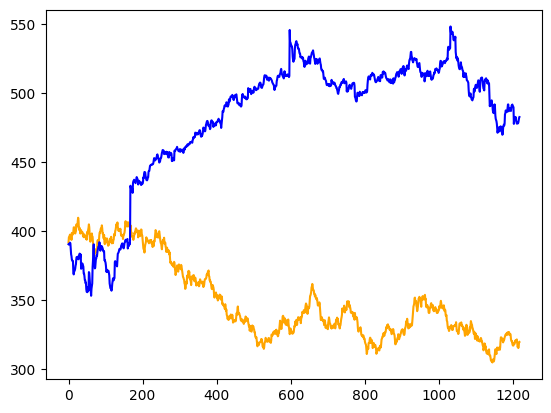

In [8]:
partition = 0.3
r = np.diff(np.log(val[:int(len(val)*partition)]))
mu = np.mean(r)
sd = np.std(r)

last = val[int(len(val)*partition)-1]

norm = np.random.normal(mu, sd, len(val)-int(len(val)*partition))
sim = last * np.exp(np.cumsum(norm))

plt.plot(sim, color='orange')
plt.plot(val[int(len(val)*partition):], color='blue')

plt.show()

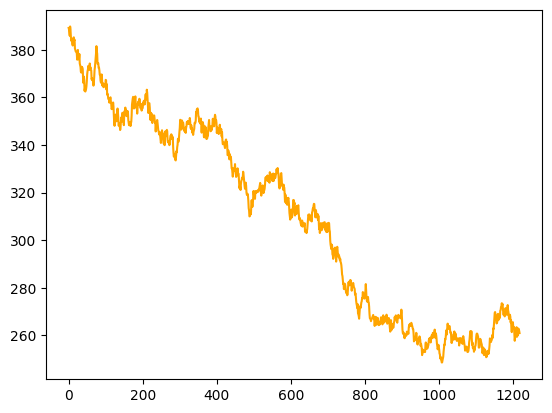

In [9]:
def brownian_prices(data:np.ndarray, steps:int):
    r = np.diff(np.log(data))
    mu = np.mean(r)
    sd = np.std(r)

    last = data[-1]

    norm = np.random.normal(mu, sd, steps)
    sim = last * np.exp(np.cumsum(norm))
    return sim

simulated_prices = brownian_prices(val[:int(len(val)*partition)], len(val)-int(len(val)*partition))
plt.plot(simulated_prices, color='orange')
plt.show()

****

Now we can build an engine that will test how good a strategy is, based on how it performs on simulated prices

In [10]:
n = 100
split = 0.3
shorts = [5, 6, 7, 8, 9]
long_coef = [2,3,4]

cut = int(len(val) * split)
history = val[:cut]
horizon = len(val) - cut

best = -np.inf
best_long = None
best_short = None

for short in shorts:
    for coef in long_coef:
        long = short * coef
        print("Short window:", short, "Long window:", long)
        total_profit = 0.0

        for j in range(n):
            sim = brownian_prices(history, horizon) #produce pices
            profit,  buy_idx, buy_prices, sell_idx, sell_prices = sma(sim, short, long) #apply strategy
            total_profit += profit

        avg_profit = total_profit / n
        print("Average profit over", n, "simulations:", avg_profit)

        if avg_profit > best:
            best = avg_profit
            best_short = short
            best_long = long
        print("-----")
    print("############")


print("Best short window:", best_short, "and best long window:", best_long, "with avg profit:", best)

Short window: 5 Long window: 10
Average profit over 100 simulations: 954.5630623794038
-----
Short window: 5 Long window: 15
Average profit over 100 simulations: 945.2794082547969
-----
Short window: 5 Long window: 20
Average profit over 100 simulations: 1137.9446472145323
-----
############
Short window: 6 Long window: 12
Average profit over 100 simulations: 727.6800224945318
-----
Short window: 6 Long window: 18
Average profit over 100 simulations: 531.1845254780405
-----
Short window: 6 Long window: 24
Average profit over 100 simulations: 766.1989852469856
-----
############
Short window: 7 Long window: 14
Average profit over 100 simulations: 996.27805730727
-----
Short window: 7 Long window: 21
Average profit over 100 simulations: 503.4138747146906
-----
Short window: 7 Long window: 28
Average profit over 100 simulations: 785.7305627563014
-----
############
Short window: 8 Long window: 16
Average profit over 100 simulations: 499.9567173244318
-----
Short window: 8 Long window: 24


Further: calulate different statistics on how good a certain algo is(e.g sharpe, alpha, beta...), add metrics for the brownian motion, maybe different simulations

# Sharpe

In [11]:
## Sharpe
import numpy as np
import pandas as pd

# parameters
short, long = 7, 28
prices = val.astype(float)

# run strategy to get signal indices
profit, buy_idx, buy_prices, sell_idx, sell_prices = sma(prices, short, long)

# build position series aligned to prices (0=flat, 1=long)
pos = np.zeros(len(prices), dtype=int)
state = 0
b_ptr, s_ptr = 0, 0
for t in range(len(prices)):
    if t < long:
        pos[t] = 0
        continue
    if b_ptr < len(buy_idx) and t == int(buy_idx[b_ptr]):
        state = 1
        b_ptr += 1
    if s_ptr < len(sell_idx) and t == int(sell_idx[s_ptr]):
        state = 0
        s_ptr += 1
    pos[t] = state

# per-bar log returns
r_price = np.zeros(len(prices))
r_price[1:] = np.log(prices[1:] / prices[:-1])

# strategy returns: use previous bar's position to avoid lookahead
r_strategy = np.zeros(len(prices))
r_strategy[1:] = pos[:-1] * r_price[1:]

# annualization factor for 1h bars (approx): 252 trading days * 6.5 hours
bars_per_year = 252 * 6.5
rf_annual = 0.0
rf_per_bar = np.log(1 + rf_annual) / bars_per_year
excess = r_strategy - rf_per_bar

mu = excess.mean()
sigma = excess.std(ddof=1)
sharpe = (mu / sigma) * np.sqrt(bars_per_year) if sigma > 0 else float('nan')

print(f"Strategy Sharpe (annualized): {sharpe:.3f}")
print(f"Samples: {len(r_strategy)}, Buys: {len(buy_idx)}, Sells: {len(sell_idx)}")
print(f"Total PnL (from sma): {profit:.2f}")

Strategy Sharpe (annualized): -0.634
Samples: 1739, Buys: 25, Sells: 16
Total PnL (from sma): -4186.60


In a function

In [12]:
def sharpe(data, profit, buy_idx, buy_prices, sell_idx, sell_prices):
    "Returns: annualized sharpe ratio of strategy"
    prices = data.astype(float)

    # build position series aligned to prices (0=flat, 1=long)
    pos = np.zeros(len(prices), dtype=int)
    state = 0
    b_ptr, s_ptr = 0, 0
    for t in range(len(prices)):
        state = 0
        if b_ptr < len(buy_idx) and t == int(buy_idx[b_ptr]):
            state = 1
            b_ptr += 1
        if s_ptr < len(sell_idx) and t == int(sell_idx[s_ptr]):
            state = 0
            s_ptr += 1
        pos[t] = state

    # per-bar log returns
    r_price = np.zeros(len(prices))
    r_price[1:] = np.log(prices[1:] / prices[:-1])

    # strategy returns: use previous bar's position to avoid lookahead
    r_strategy = np.zeros(len(prices))
    r_strategy[1:] = pos[:-1] * r_price[1:]

    # annualization factor for 1h bars (approx): 252 trading days * 6.5 hours
    bars_per_year = 252 * 6.5
    rf_annual = 0.0
    rf_per_bar = np.log(1 + rf_annual) / bars_per_year

    excess = r_strategy - rf_per_bar

    mu = excess.mean()
    sigma = excess.std(ddof=1)
    sharpe = (mu / sigma) * np.sqrt(bars_per_year) if sigma > 0 else float('nan')

    return sharpe

In [13]:
n = 1000
total_profit = 0.0
sharpes = np.array([])
for j in range(n):
    sim = brownian_prices(history, horizon) #produce pices
    profit,  buy_idx, buy_prices, sell_idx, sell_prices = sma(sim, short, long) #apply strategy
    sharpe_ratio = sharpe(sim, profit, buy_idx, buy_prices, sell_idx, sell_prices) 
    sharpes = np.append(sharpes, sharpe_ratio)
    total_profit += profit

print(f"Average profit over {n} simulations: {total_profit/n:.2f}")
print(f"Average Sharpe ratio over {n} simulations: {np.nanmean(sharpes):.3f}, Std: {np.nanstd(sharpes):.3f}")
print(f"Best sharpe:{np.nanmax(sharpes):.3f}, Worst sharpe:{np.nanmin(sharpes):.3f}")

Average profit over 1000 simulations: 680.03
Average Sharpe ratio over 1000 simulations: -0.183, Std: 1.142
Best sharpe:3.042, Worst sharpe:-3.059
